<a href="https://colab.research.google.com/github/gryali/Geospatial-Machine-Learning/blob/main/Optimized_Spatially_aware_LightGBM_RHm_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spatially-Aware Machine Learning: Canopy Height Modelling**

In [ ]:
# Import the EE API
import ee

# EE Authentication
ee.Authenticate()

# Initialize EE project
ee.Initialize(project='ee-satellite-timeseries')

/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [ ]:
# Install dependencies
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.3 MB/s eta 0:00:00


In [ ]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# ----------------------------------------------------
import sys
import math
import random
from math import sqrt
# ----------------------------------------------------
## Machine Learning Regressor
import lightgbm as lgb

## Machine Learning Optimizer
import optuna
# ----------------------------------------------------

**Sample extrantion from GEDI L2A (canopy height) Footprints**

In [ ]:
# Load Preprocessed GEDI L2A Footprints
GEDIfc = ee.FeatureCollection('projects/ee-satellite-timeseries/assets/Mor_GEDIL2A_2020')

In [ ]:
# Retrieve RHm values using the 'rhmean' property
RHm_values = GEDIfc.aggregate_array('rhmean').getInfo()

# Calculate summary statistics
mean_RHm = np.mean(RHm_values)
median_RHm = np.median(RHm_values)
std_RHm = np.std(RHm_values)
min_RHm = np.min(RHm_values)
max_RHm = np.max(RHm_values)

# Print the summary statistics
print("Mean RHm:", mean_RHm)
print("Median RHm:", median_RHm)
print("Standard Deviation RHm:", std_RHm)
print("Minimum RHm:", min_RHm)
print("Maximum RHm:", max_RHm)

Mean RHm: 21.927464573945404
Median RHm: 21.389999000000003
Standard Deviation RHm: 13.159667950781447
Minimum RHm: 0.25999999046325684
Maximum RHm: 142.1849975


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


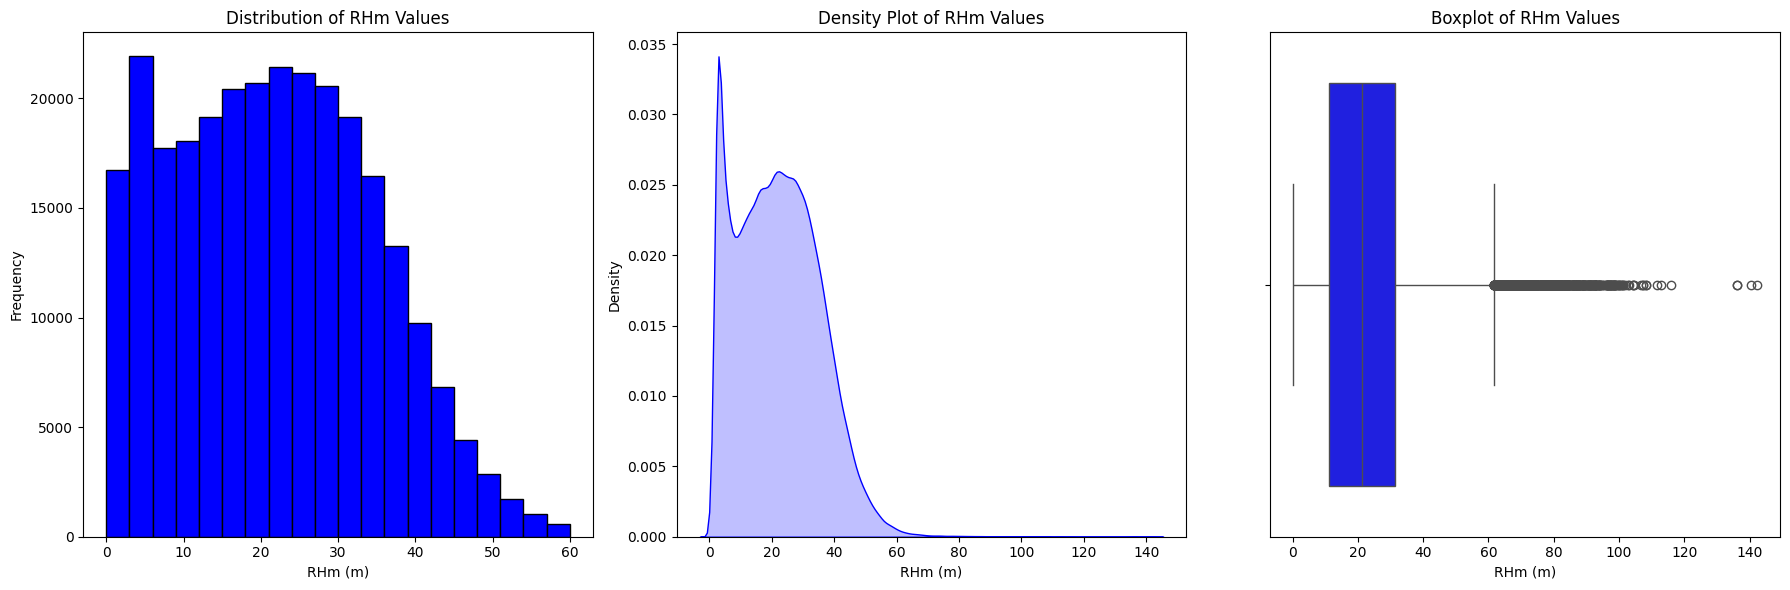

In [ ]:
# Specify figure dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot a histogram of RHm values
axes[0].hist(RHm_values, bins=20, range=[0, 60], color='blue', edgecolor='black')
axes[0].set_xlabel('RHm (m)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of RHm Values')

# Plot a density plot of RHm values using seaborn (updated argument)
sns.kdeplot(RHm_values, fill=True, color='blue', ax=axes[1])
axes[1].set_xlabel('RHm (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('Density Plot of RHm Values')

# Plot a boxplot of RHm values using seaborn
sns.boxplot(x=RHm_values, color='blue', ax=axes[2])
axes[2].set_xlabel('RHm (m)')
axes[2].set_title('Boxplot of RHm Values')

# Adjust layout for better display
plt.tight_layout()
plt.show()

In [ ]:
# Filter the training points by range (0m to 60m) based on Lang et el. (2023) - High resolution canopy height model of the earth
filteredPoints = GEDIfc.filter(
    ee.Filter.And(
        ee.Filter.gte('rhmean', 0),
        ee.Filter.lte('rhmean', 60)
    )
)

In [ ]:
# Adjustment: Add a uniform distribution random value column to the FeatureCollection.
fc = filteredPoints.randomColumn('random', 42)

# Randomly split the collection into two sets of the total dataset.
data = fc.filter(ee.Filter.lt('random', 0.020361625))
print('~2.04% of N:', data.size().getInfo())

unsampled = fc.filter(ee.Filter.gte('random', 0.020361625))

~2.04% of N: 5500


/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


**Creation of Fused Model Composite**

In [ ]:
# # -------------------------------------------------------------
# # Load Feature Engineered Model Composite
# # -------------------------------------------------------------
# # **************************************************************************************
# Loand Pre-proceced AlphaEarth Satellite Embedding Composite
SE_ModelComp = ee.Image('projects/ee-satellite-timeseries/assets/SatelliteEmbeddings/SE_Composite2020_30m')
SE_MC = SE_ModelComp.select(['A01', 'A02', 'A06', 'A07', 'A12', 'A17', 'A23', 'A25', 'A27', 'A30', 'A31', 'A33', 'A34', 'A35', 'A36', 'A39', 'A43', 'A44', 'A45', 'A46', 'A49', 'A50', 'A55', 'A56', 'A58'])

# Load Fused Sentinel-1 & Sentinel-2 Composite from GEE
MSC = ee.Image('projects/ee-satellite-timeseries/assets/FS_ModelComposite_2020')
MS_MC = MSC.select(['S1_Poldiff', 'S1_Polsqrt', 'S1_PC2', 'S1_p25', 'S1_p50', 'S2_B2', 'S2_B4', 'S2_B8', 'S2_B11', 'S2_NDVI', 'S2_NDII', 'S2_CVI', 'S2_GLI', 'S2_VARI', 'S2_PSRI', 'S2_PC4', 'S2_PC5', 'S2_PC6'])

# Loabd Environmetal Composite from GEE
EC = ee.Image('projects/ee-satellite-timeseries/assets/FS_Env_MC_2020')

# Create Fused Model Composite
ModelComp = MS_MC.addBands([EC, SE_MC])
# **************************************************************************************

In [ ]:
# Get a list of all band names
bands = ModelComp.bandNames()

# Print the list of bands to verify
print("All bands in the image:", bands.getInfo())

All bands in the image: ['S1_Poldiff', 'S1_Polsqrt', 'S1_PC2', 'S1_p25', 'S1_p50', 'S2_B2', 'S2_B4', 'S2_B8', 'S2_B11', 'S2_NDVI', 'S2_NDII', 'S2_CVI', 'S2_GLI', 'S2_VARI', 'S2_PSRI', 'S2_PC4', 'S2_PC5', 'S2_PC6', 'FABDEM', 'Slope', 'Aspect', 'meanTemp', 'meanPrec', 'A01', 'A02', 'A06', 'A07', 'A12', 'A17', 'A23', 'A25', 'A27', 'A30', 'A31', 'A33', 'A34', 'A35', 'A36', 'A39', 'A43', 'A44', 'A45', 'A46', 'A49', 'A50', 'A55', 'A56', 'A58']


**Model Configs**

In [ ]:
# Input GEDI Sample
grain_size = 25
footprints = ee.FeatureCollection(data)
FS = 'rhmean'

# Tuning Seed
TUNING_SEED = 42
np.random.seed(TUNING_SEED)

# Spatial CV Folds
NUM_FOLDS = 5

# Export Folder in Google Drive
EXPORT_FOLDER = 'SpBCV_Optimal_SA_LGBM_FS_Model'

**Model Execution: Spatially-aware LightGBM Optimization Framework**

In [ ]:
# ===================================================================================
# SA-LGBM: LIGHTGBM + EIGENVECTOR SPATIAL FILTERING + SPATIAL CV WITH OOF PREDICTIONS
# ===================================================================================
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. DATA RETRIEVAL & CLEANING HELPERS
# ============================================================

def get_samples_to_dataframe_tiled(image, feature_collection, bands_list, target_property, grain_size=25, batch_size=2000):
    """
    Retrieves GEE data in batches to bypass the 5000-element limit and prevents FATAL ERROR.
    """
    if isinstance(bands_list, ee.List):
        bands_list = bands_list.getInfo()

    # Add coordinates to the image bands
    image_with_coords = image.addBands(ee.Image.pixelLonLat())

    # Create the sample collection on the GEE server
    samples_fc = image_with_coords.sampleRegions(
        collection=feature_collection,
        properties=[target_property],
        scale=grain_size,
        geometries=False
    )

    # Get total count to plan the batch loops
    total_count = samples_fc.size().getInfo()
    print(f"GEE: {total_count} total samples found. Retrieving in batches of {batch_size}...")

    properties_to_extract = list(bands_list) + [target_property, 'longitude', 'latitude']
    all_rows = []

    # Iterate through the collection in increments of batch_size
    for i in range(0, total_count, batch_size):
        try:
            # Slicing the FeatureCollection on the server side
            batch = ee.FeatureCollection(samples_fc.toList(batch_size, i))
            data_list = batch.select(properties_to_extract).getInfo()['features']

            rows = [f['properties'] for f in data_list]
            all_rows.extend(rows)
            print(f"  - Progress: {len(all_rows)} / {total_count}")

        except Exception as e:
            print(f"  - Error at batch index {i}: {e}")
            continue

    if not all_rows:
        print("Warning: No data returned from GEE.")
        return pd.DataFrame(), pd.Series(), pd.DataFrame()

    df = pd.DataFrame(all_rows)

    # Drop rows with missing values (common in GEE sampling near edges/clouds)
    df = df.dropna(subset=bands_list + [target_property])

    X = df[bands_list]
    y = df[target_property]
    coords = df[['longitude', 'latitude']]

    return X, y, coords

def remove_spatial_outliers(X, y, coords, contamination=0.067):
    """Removes spatial/spectral outliers using Local Outlier Factor."""
    if X.empty:
        raise ValueError("Cannot remove outliers: Input DataFrame is empty.")

    print(f"--- Starting Outlier Detection (Contamination: {contamination}) ---")
    print(f"Original samples: {len(X)}")

    lof_input = np.hstack([
        StandardScaler().fit_transform(X),
        StandardScaler().fit_transform(coords)
    ])
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    is_inlier = lof.fit_predict(lof_input) == 1

    print(f"Samples after outlier removal: {np.sum(is_inlier)}")
    return X[is_inlier].reset_index(drop=True), y[is_inlier].reset_index(drop=True), coords[is_inlier].reset_index(drop=True)

# ============================================================
# 2. SPATIAL BLOCKING LOGIC
# ============================================================

def build_spatial_groups(coords_df, block_size_m=5000):
    """Assigns spatial grid IDs and block extents."""
    lons = coords_df['longitude'].values
    lats = coords_df['latitude'].values
    minx, maxx = np.min(lons), np.max(lons)
    miny, maxy = np.min(lats), np.max(lats)
    mid_lat = np.mean(lats)

    deg_per_m_lat = 1 / 111320.0
    deg_per_m_lon = 1 / (111320.0 * math.cos(math.radians(mid_lat)))

    dx = block_size_m * deg_per_m_lon
    dy = block_size_m * deg_per_m_lat

    col_indices = np.floor((lons - minx) / dx).astype(int)
    row_indices = np.floor((lats - miny) / dy).astype(int)

    num_cols = int(np.ceil((maxx - minx) / dx))
    num_rows = int(np.ceil((maxy - miny) / dy))

    col_indices = np.clip(col_indices, 0, max(0, num_cols - 1))
    row_indices = np.clip(row_indices, 0, max(0, num_rows - 1))

    point_grid = np.char.add(
        np.char.add("G", col_indices.astype(str)),
        np.char.add("_", row_indices.astype(str))
    )

    unique_grids = np.unique(point_grid)
    grid_blocks = {}
    for gid in unique_grids:
        _, c_r = gid.split('G')
        c, r = map(int, c_r.split('_'))
        x0 = minx + c * dx
        y0 = miny + r * dy
        grid_blocks[gid] = (x0, y0, x0 + dx, y0 + dy)

    return point_grid, grid_blocks, minx, maxx, miny, maxy, lons, lats

def get_trainable_mask(lons, lats, test_grids, grid_blocks, buffer_m=1500):
    """Returns boolean mask indicating points safe for training (outside buffer)."""
    buffer_deg = buffer_m / 111320.0
    unsafe_mask = np.zeros_like(lons, dtype=bool)
    for gid in test_grids:
        x0, y0, x1, y1 = grid_blocks[gid]
        unsafe_mask |= (
            (lons >= x0 - buffer_deg) & (lons <= x1 + buffer_deg) &
            (lats >= y0 - buffer_deg) & (lats <= y1 + buffer_deg)
        )
    return ~unsafe_mask

# ============================================================
# 3. Compute Spatial Eigen Vectors
# ============================================================

def compute_spatial_eigenvectors(coords_df, n_ev=15, moran_threshold=0.1):
    """Constructs ESF eigenvectors filtered by Moran's I."""
    print(f"Generating spatial eigenvectors (Moran's I > {moran_threshold})...")
    coords = coords_df[['longitude','latitude']].values
    dist_matrix = squareform(pdist(coords))
    sigma = np.mean(dist_matrix)
    W = np.exp(-dist_matrix**2 / (2*sigma**2))
    np.fill_diagonal(W, 0)

    n = W.shape[0]
    M = np.eye(n) - np.ones((n,n))/n
    B = M @ W @ M

    eigenvalues, eigenvectors = np.linalg.eigh(B)
    idx = np.argsort(eigenvalues)[::-1]
    sorted_evs = eigenvectors[:, idx[:100]]

    sum_W = np.sum(W)
    useful_evs = []
    for i in range(sorted_evs.shape[1]):
        ev = sorted_evs[:, i]
        morans_i = (n/sum_W) * (ev.T @ W @ ev) / (ev.T @ ev)
        if morans_i > moran_threshold:
            useful_evs.append(ev)
            if len(useful_evs) >= n_ev:
                break

    if not useful_evs:
        print("Warning: No eigenvectors met threshold. Using first eigenvector.")
        useful_evs = [sorted_evs[:,0]]

    ev_cols = [f'EV_{i+1}' for i in range(len(useful_evs))]
    print(f"Kept {len(useful_evs)} spatial eigenvectors.")
    return pd.DataFrame(np.column_stack(useful_evs), columns=ev_cols)

# ============================================================
# 4. SA_LGBM OPTUNA OBJECTIVE
# ============================================================

def make_sa_lgbm_objective(X, y, point_grid, grid_blocks, lons, lats, num_folds=5, seed=42):
    populated_grid_ids = list(np.unique(point_grid))
    random.seed(seed)
    random.shuffle(populated_grid_ids)
    folds = [populated_grid_ids[i::num_folds] for i in range(num_folds)]

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "verbosity": -1,
            "boosting_type": 'gbdt',
            "random_state": seed,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 128),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }

        n_estimators = trial.suggest_int("n_estimators", 100, 1000)
        rmses, r2_scores = [], []

        for fold_idx in range(num_folds):
            test_blocks = folds[fold_idx]
            is_test = np.isin(point_grid, test_blocks)
            safe_train_mask = get_trainable_mask(lons, lats, test_blocks, grid_blocks)
            trainable_mask = (~is_test) & safe_train_mask

            X_train, y_train = X.iloc[trainable_mask], y.iloc[trainable_mask]
            X_valid, y_valid = X.iloc[is_test], y.iloc[is_test]

            model = lgb.LGBMRegressor(**params, n_estimators=n_estimators)
            model.fit(
                X_train, y_train,
                eval_set=[(X_valid, y_valid)],
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )

            preds = model.predict(X_valid)
            rmses.append(sqrt(mean_squared_error(y_valid, preds)))
            r2_scores.append(r2_score(y_valid, preds))

        trial.set_user_attr("mean_r2", float(np.mean(r2_scores)))
        return float(np.mean(rmses))

    return objective

# ============================================================
# 5. FULL MODEL PIPELINE EXECUTION
# ============================================================

TUNING_SEED = 42
np.random.seed(TUNING_SEED)

# A. Sample & Clean Data (Using Tiled Retrieval)
# ModelComp, footprints, bands, FS must be defined in your environment
X_raw_dirty, y_dirty, coords_dirty = get_samples_to_dataframe_tiled(ModelComp, footprints, bands, FS)

if X_raw_dirty.empty:
    print("CRITICAL ERROR: No data retrieved from GEE. Check your collection or credentials.")
else:
    # B. Outlier Removal
    X_clean, y_clean, coords_clean = remove_spatial_outliers(X_raw_dirty, y_dirty, coords_dirty, contamination=0.067)

    # C. Build Spatial Eigenvectors and Merge
    spatial_evs = compute_spatial_eigenvectors(coords_clean, n_ev=15, moran_threshold=0.1)
    X_tune = pd.concat([X_clean, spatial_evs], axis=1)

    # D. Build Spatial Groups
    point_grid, grid_blocks, minx, maxx, miny, maxy, lons, lats = build_spatial_groups(coords_clean)

    # E. Optuna Tuning
    print("--- Starting Spatiall-aware LightGBM Tuning ---")
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=TUNING_SEED))
    study.optimize(
        make_sa_lgbm_objective(X_tune, y_clean, point_grid, grid_blocks, lons, lats, seed=TUNING_SEED),
        n_trials=100,
        show_progress_bar=True
    )

    best_params = study.best_params
    n_est = best_params.pop('n_estimators')

    print(f"Best Mean RMSE: {study.best_value:.4f}")
    print(f"Best Mean R²: {study.best_trial.user_attrs['mean_r2']:.4f}")

    # F. Generate Out-of-Fold Predictions
    NUM_FOLDS = 5
    populated_grid_ids = sorted(list(np.unique(point_grid)))
    random.seed(TUNING_SEED)
    random.shuffle(populated_grid_ids)
    folds = [populated_grid_ids[i::NUM_FOLDS] for i in range(NUM_FOLDS)]

    oof_preds = np.zeros(len(y_clean))

    for k in range(NUM_FOLDS):
        test_blocks = folds[k]
        is_test = np.isin(point_grid, test_blocks)
        va_idx = np.where(is_test)[0]
        tr_idx = np.where((~is_test) & get_trainable_mask(lons, lats, test_blocks, grid_blocks))[0]

        m = lgb.LGBMRegressor(**best_params, n_estimators=n_est, random_state=TUNING_SEED)
        m.fit(X_tune.iloc[tr_idx], y_clean.iloc[tr_idx])
        oof_preds[va_idx] = m.predict(X_tune.iloc[va_idx])

    # Performance Reporting
    oof_rmse = sqrt(mean_squared_error(y_clean, oof_preds))
    oof_r2 = r2_score(y_clean, oof_preds)
    print(f"--- Out-of-Fold Performance ---")
    print(f"OOF RMSE: {oof_rmse:.4f}")
    print(f"OOF R²: {oof_r2:.4f}")

    # G. Final Model
    final_model = lgb.LGBMRegressor(**best_params, n_estimators=n_est, random_state=TUNING_SEED)
    final_model.fit(X_tune, y_clean)
    print("--- Spatiall-aware LightGBM Execution Complete ---")


GEE: 4949 total samples found. Retrieving in batches of 2000...
  - Progress: 2000 / 4949
  - Progress: 4000 / 4949
  - Progress: 4949 / 4949
--- Starting Outlier Detection (Contamination: 0.067) ---
Original samples: 4949
Samples after outlier removal: 4617
Generating spatial eigenvectors (Moran's I > 0.1)...


[I 2026-06-28 03:32:08,556] A new study created in memory with name: no-name-c67802be-4dfd-4f7d-a94e-8dafeb4dcc6a


Kept 3 spatial eigenvectors.
--- Starting Spatiall-aware LightGBM Tuning ---


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-28 03:32:11,606] Trial 0 finished with value: 8.057616430709604 and parameters: {'learning_rate': 0.019906996673933378, 'num_leaves': 123, 'max_depth': 10, 'min_child_samples': 62, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014, 'bagging_freq': 1, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'n_estimators': 737}. Best is trial 0 with value: 8.057616430709604.
[I 2026-06-28 03:32:19,723] Trial 1 finished with value: 8.253941323878047 and parameters: {'learning_rate': 0.005394455304087533, 'num_leaves': 125, 'max_depth': 11, 'min_child_samples': 25, 'feature_fraction': 0.5909124836035503, 'bagging_fraction': 0.5917022549267169, 'bagging_freq': 3, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'n_estimators': 362}. Best is trial 0 with value: 8.057616430709604.
[I 2026-06-28 03:32:21,345] Trial 2 finished with value: 8.074387089290076 and parameters: {'learning_rate': 0.04777437867054351, 'num_leaves

**Model Optimisation Results**

In [ ]:
# Print the best hyperparameters and the corresponding RMSE
print("Best hyperparameters: ", study.best_params)
print("Best RMSE: ", study.best_value)

Best hyperparameters:  {'learning_rate': 0.017230706648181063, 'num_leaves': 76, 'max_depth': 5, 'min_child_samples': 52, 'feature_fraction': 0.6391207225153314, 'bagging_fraction': 0.6327859127992069, 'bagging_freq': 1, 'reg_alpha': 1.0969022507777814e-06, 'reg_lambda': 9.296878188144753, 'n_estimators': 426}
Best RMSE:  8.025729729006244


In [ ]:
#Plot optimization
optuna.visualization.plot_optimization_history(study)

**Model Feature Importance**

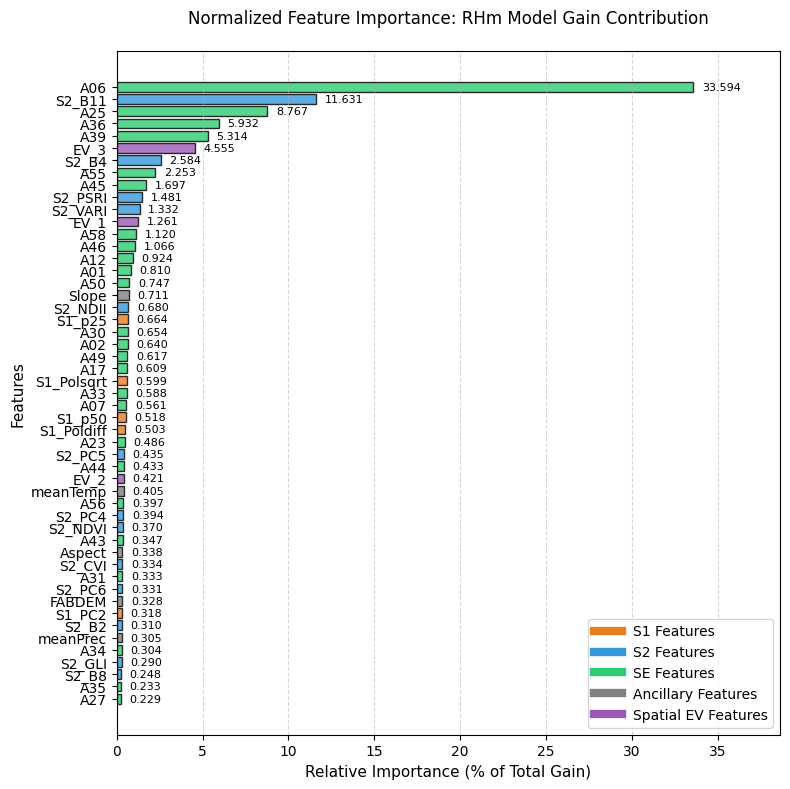

In [ ]:
# ---------------------------------------------------------
# Feature Importance Plotting (Normalized & Multi-Category)
# ---------------------------------------------------------
import re
from matplotlib.lines import Line2D

# 1. Accessing importance (Total Gain)
feature_importance = final_model.booster_.feature_importance(importance_type='gain')

# 2. Create DataFrame and Normalize
# We divide by the sum of all importance values to get a 0-1 range (Relative Importance)
importance_df = pd.DataFrame({
    'Feature': X_tune.columns,
    'Importance': feature_importance
})

# Normalization Step: Convert to percentage (0-100)
total_gain = importance_df['Importance'].sum()
importance_df['Importance_Pct'] = (importance_df['Importance'] / total_gain) * 100

# Sort the features by normalized importance
importance_df = importance_df.sort_values(by='Importance_Pct', ascending=True)

# 3. Define Color Logic for 3+ Categories
def get_color(feature_name):
    if 'EV_' in feature_name:
        return '#9b59b6'  # Purple: Spatial EVs
    # Use regex to match exactly 'A' followed by one or more digits (e.g., A0, A12, A99)
    elif re.match(r'^A\d+$', feature_name):
        return '#2ecc71'  # Green: AlphaEarthSatellite Embedding (A##)
    elif feature_name.startswith('S1'):
        return '#e67e22'  # Orange: S1
    elif feature_name.startswith('S2'):
        return '#3498db'  # Blue: S2
    else:
        return '#808080'  # (Default): Ancillary

colors = [get_color(f) for f in importance_df['Feature']]

# 4. Plotting
plt.figure(figsize=(8, 8))

# Use 'Importance_Pct' for the bar widths
plt.barh(importance_df['Feature'], importance_df['Importance_Pct'],
         color=colors, edgecolor='black', alpha=0.8)

# 5. Add a Custom Legend
legend_elements = [
    Line2D([0], [0], color='#e67e22', lw=6, label='S1 Features'),
    Line2D([0], [0], color='#3498db', lw=6, label='S2 Features'),
    Line2D([0], [0], color='#2ecc71', lw=6, label='SE Features'),
    Line2D([0], [0], color='#808080', lw=6, label='Ancillary Features'),
    Line2D([0], [0], color='#9b59b6', lw=6, label='Spatial EV Features')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)

# 6. Formatting
plt.xlabel('Relative Importance (% of Total Gain)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.title('Normalized Feature Importance: RHm Model Gain Contribution',
          fontsize=12, pad=20)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, importance_df['Importance_Pct'].max() * 1.15) # Add padding for labels

# 7. Add text labels (Showing % values for the top 50)
for i, (v, name) in enumerate(zip(importance_df['Importance_Pct'], importance_df['Feature'])):
    if i > len(importance_df) - 52: # Label only the top 50
        plt.text(v + 0.5, i, f'{v:.3f}',
                 va='center', fontsize=8)

plt.tight_layout()
plt.show()


**Model Diagnostics**

In [ ]:
# ==============================================================================
# DIAGNOSTIC RUN: Calculate Metrics Per Fold
# ==============================================================================

print("--- Running Final Spatially-aware LightGBM Spatial CV Diagnostics ---")

# ------------------------------------------------------------------------------
# 1. Recreate Spatial Folds (EXACT MATCH to tuning logic)
# ------------------------------------------------------------------------------

# EXACT replication of tuning logic (NO sorting)
populated_grid_ids = list(np.unique(point_grid))
random.seed(TUNING_SEED)
random.shuffle(populated_grid_ids)

folds = [populated_grid_ids[i::NUM_FOLDS] for i in range(NUM_FOLDS)]

fold_metrics = []

# Use same feature set used during tuning
X_df = X_tune
y_df = y_clean

# ------------------------------------------------------------------------------
# 2. Spatial CV Diagnostics Loop
# ------------------------------------------------------------------------------

for k in range(NUM_FOLDS):

    # A. Identify Train / Test Split
    test_blocks = folds[k]
    is_test = np.isin(point_grid, test_blocks)

    # B. Apply Spatial Buffer Logic as tuning (1500m)
    safe_train_mask = get_trainable_mask(
        lons,
        lats,
        test_blocks,
        grid_blocks,
        buffer_m=1500
    )

    trainable_mask = (~is_test) & safe_train_mask

    tr_idx = np.where(trainable_mask)[0]
    va_idx = np.where(is_test)[0]

    n_train = len(tr_idx)
    n_test  = len(va_idx)

    if n_train == 0 or n_test == 0:
        print(f"Skipping Fold {k + 1} (Empty split)")
        continue

    # C. Train Fold Model Using Best Hyperparameters
    model_fold = lgb.LGBMRegressor(
        **best_params,
        n_estimators=n_est,
        random_state=TUNING_SEED,
        objective="regression",
        metric="rmse",
        boosting_type="gbdt",
        verbosity=-1,
        importance_type="gain"
    )

    model_fold.fit(
        X_df.iloc[tr_idx],
        y_df.iloc[tr_idx],
        eval_set=[(X_df.iloc[va_idx], y_df.iloc[va_idx])],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # D. Predict & Evaluate
    preds  = model_fold.predict(X_df.iloc[va_idx])
    y_true = y_df.iloc[va_idx]

    rmse = sqrt(mean_squared_error(y_true, preds))
    mae  = mean_absolute_error(y_true, preds)
    r2   = r2_score(y_true, preds)

    print(
        f"Fold {k + 1}: "
        f"Train N={n_train}, Test N={n_test} | "
        f"RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}"
    )

    fold_metrics.append({
        "Fold":    k + 1,
        "N_Train": n_train,
        "N_Test":  n_test,
        "RMSE":    rmse,
        "MAE":     mae,
        "R²":      r2
    })

# ------------------------------------------------------------------------------
# 3. Summary Statistics
# ------------------------------------------------------------------------------

metrics_df = pd.DataFrame(fold_metrics)

print("-" * 60)
print("Spatiall-aware LGBM SPATIAL CV SUMMARY")
print("-" * 60)
print(metrics_df.to_string(index=False))
print("-" * 60)

mean_r2   = metrics_df["R²"].mean()
std_r2    = metrics_df["R²"].std()
mean_rmse = metrics_df["RMSE"].mean()
std_rmse  = metrics_df["RMSE"].std()

print(f"Mean R²:   {mean_r2:.4f} (±{std_r2:.4f})")
print(f"Mean RMSE: {mean_rmse:.4f} (±{std_rmse:.4f})")
print("-" * 60)

--- Running Final Spatially-aware LightGBM Spatial CV Diagnostics ---
Fold 1: Train N=2665, Test N=909 | RMSE=8.0783, MAE=6.2225, R²=0.5797
Fold 2: Train N=2566, Test N=1021 | RMSE=7.9014, MAE=6.0051, R²=0.6137
Fold 3: Train N=2842, Test N=921 | RMSE=7.9740, MAE=6.0880, R²=0.5539
Fold 4: Train N=2830, Test N=835 | RMSE=8.3653, MAE=6.3678, R²=0.5702
Fold 5: Train N=2766, Test N=931 | RMSE=7.8096, MAE=5.8617, R²=0.6633
------------------------------------------------------------
Spatiall-aware LGBM SPATIAL CV SUMMARY
------------------------------------------------------------
 Fold  N_Train  N_Test     RMSE      MAE       R²
    1     2665     909 8.078266 6.222507 0.579678
    2     2566    1021 7.901425 6.005136 0.613742
    3     2842     921 7.974026 6.087955 0.553926
    4     2830     835 8.365337 6.367845 0.570191
    5     2766     931 7.809595 5.861736 0.663302
------------------------------------------------------------
Mean R²:   0.5962 (±0.0434)
Mean RMSE: 8.0257 (±0.2139)
-


--- Computing OOF Predictions for Moran's I Diagnostics ---


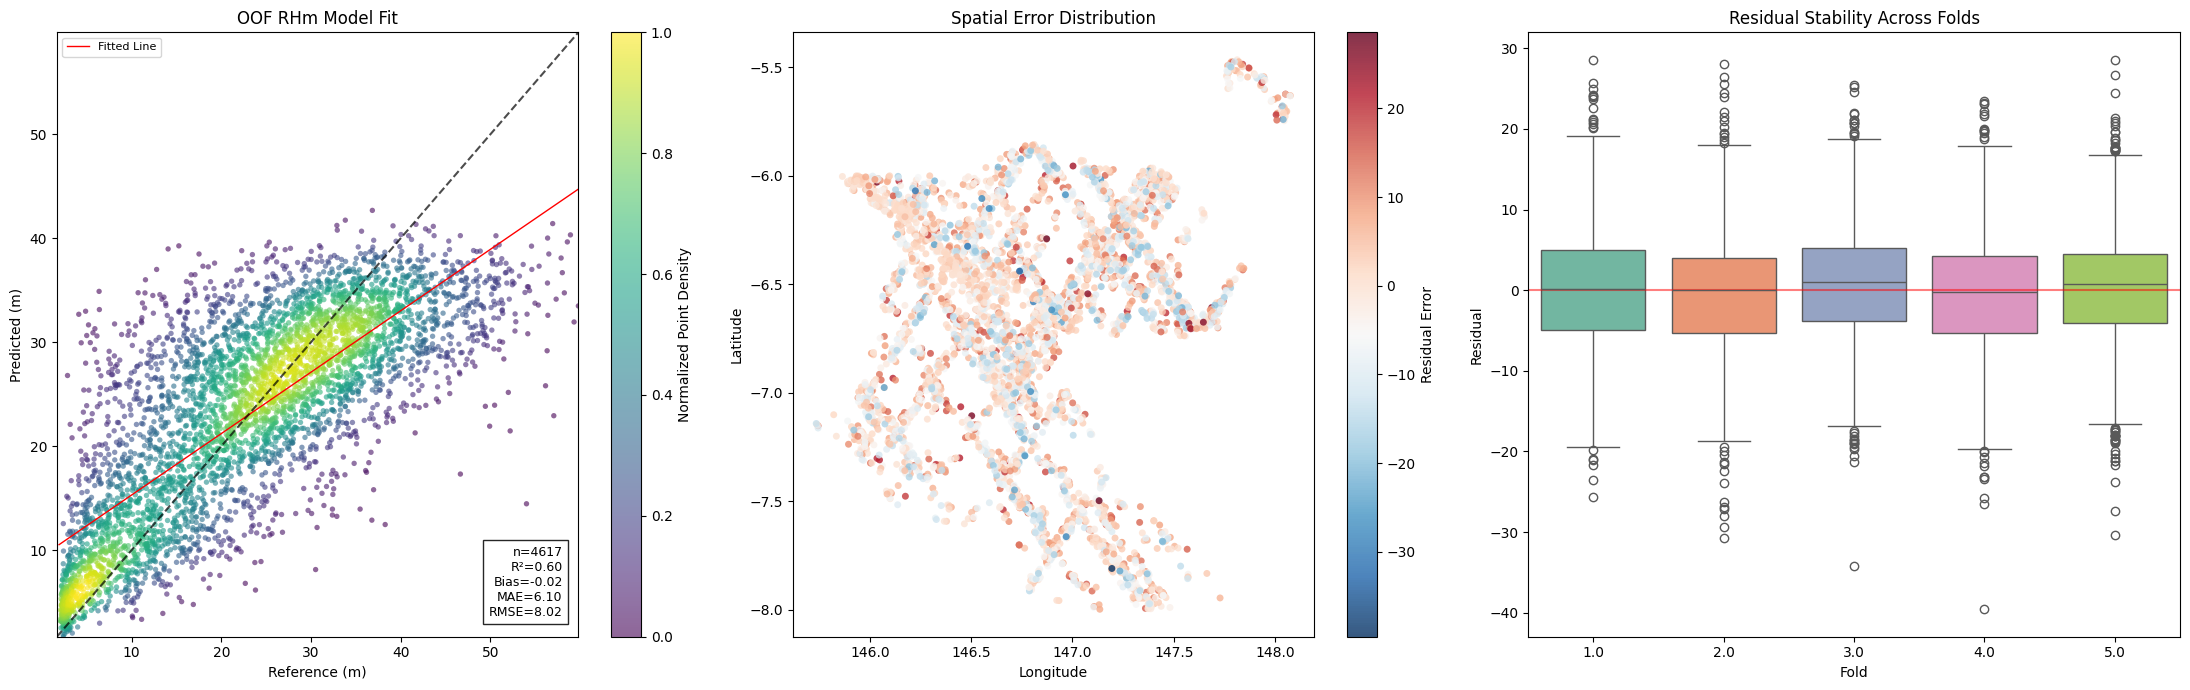

In [18]:
# ===============================================================================
# OOF MODEL FITTING & RESIDUAL DISTRIBUTION + SPATIAL AUTOCORRELATION DIAGNOSTICS
# ===============================================================================
# ------------------------------------------------------------------------------
# REQUIRED IMPORTS
# ------------------------------------------------------------------------------

import statsmodels.api as sm
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde

# ------------------------------------------------------------------------------
# 1. GLOBAL MORAN'S I
# ------------------------------------------------------------------------------

def calculate_residual_autocorrelation(coords_array, residuals):
    """
    Computes Global Moran's I using Gaussian kernel weighting.
    """
    n = len(residuals)
    z = residuals - np.mean(residuals)

    dist_matrix = squareform(pdist(coords_array))
    sigma = np.mean(dist_matrix)

    W = np.exp(-dist_matrix**2 / (2 * sigma**2))
    np.fill_diagonal(W, 0)

    sum_w = np.sum(W)
    numerator = n * (z.T @ W @ z)
    denominator = sum_w * (z.T @ z)

    return numerator / denominator


# ------------------------------------------------------------------------------
# 2. SPATIAL CV OOF PREDICTIONS
# ------------------------------------------------------------------------------

print("\n--- Computing OOF Predictions for Moran's I Diagnostics ---")

populated_grid_ids = list(np.unique(point_grid))
random.seed(TUNING_SEED)
random.shuffle(populated_grid_ids)
folds = [populated_grid_ids[i::NUM_FOLDS] for i in range(NUM_FOLDS)]

oof_preds = np.full(len(y_clean), np.nan)
fold_tracker = np.full(len(y_clean), np.nan)

for k in range(NUM_FOLDS):

    test_blocks = folds[k]
    is_test = np.isin(point_grid, test_blocks)

    # Apply Spatial Buffer Logic as tuning (1500m)
    safe_train_mask = get_trainable_mask(
        lons,
        lats,
        test_blocks,
        grid_blocks,
        buffer_m=1500
    )

    trainable_mask = (~is_test) & safe_train_mask

    tr_idx = np.where(trainable_mask)[0]
    va_idx = np.where(is_test)[0]

    if len(tr_idx) == 0 or len(va_idx) == 0:
        print(f"Skipping Fold {k+1}")
        continue

    model_fold = lgb.LGBMRegressor(
        **best_params,
        n_estimators=n_est,
        random_state=TUNING_SEED,
        objective="regression",
        metric="rmse",
        boosting_type="gbdt",
        verbosity=-1,
        importance_type="gain"
    )

    model_fold.fit(
        X_tune.iloc[tr_idx],
        y_clean.iloc[tr_idx],
        eval_set=[(X_tune.iloc[va_idx], y_clean.iloc[va_idx])],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    oof_preds[va_idx] = model_fold.predict(X_tune.iloc[va_idx])
    fold_tracker[va_idx] = k + 1

valid_mask = ~np.isnan(oof_preds)

y_oof = y_clean.iloc[valid_mask].values
pred_oof = oof_preds[valid_mask]
coords_oof = coords_clean.iloc[valid_mask]
grid_oof = point_grid[valid_mask]
fold_oof = fold_tracker[valid_mask]


# ------------------------------------------------------------------------------
# 3. VISUALIZATION FUNCTION (FIXED VERSION)
# ------------------------------------------------------------------------------

def visualize_spatial_performance(y_true, y_pred, coords_df, point_grid, fold_tracker):
    """
    Diagnostic suite using high-fidelity density plotting, normalized scatter,
    spatial metrics, and OLS regression with 95% CI & PI.
    """
    results = coords_df.copy()
    results['ref'] = y_true
    results['pred'] = y_pred
    results['error'] = y_pred - y_true
    results['grid'] = point_grid
    results['fold'] = fold_tracker

    # Calculate Moran's I on the residuals
    m_i = calculate_residual_autocorrelation(
        coords_df[['longitude', 'latitude']].values,
        results['error'].values
    )

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # ==========================================================
    # PANEL 1 — DENSITY SCATTER + NORMALIZATION + OLS + CI + PI
    # ==========================================================
    x_plot, y_plot = results['ref'].values, results['pred'].values

    # Density calculation with normalization
    try:
        xy = np.vstack([x_plot, y_plot])
        if len(x_plot) > 10000:
            idx_sub = np.random.choice(len(x_plot), 5000, replace=False)
            z = gaussian_kde(xy[:, idx_sub])(xy)
        else:
            z = gaussian_kde(xy)(xy)

        # Normalize density values to 0–1
        z_norm = (z - z.min()) / (z.max() - z.min())
        idx_sort = z_norm.argsort()

        sc = axes[0].scatter(
            x_plot[idx_sort],
            y_plot[idx_sort],
            c=z_norm[idx_sort],
            cmap='viridis',
            s=15,
            alpha=0.6,
            edgecolor='none'
        )
        plt.colorbar(sc, ax=axes[0], label='Normalized Point Density')

    except Exception:
        axes[0].scatter(x_plot, y_plot, alpha=0.3, s=10, color='teal')

    # OLS regression
    X = sm.add_constant(x_plot)
    model = sm.OLS(y_plot, X).fit()

    x_pred = np.linspace(x_plot.min(), x_plot.max(), 200)
    X_pred = sm.add_constant(x_pred)
    pred_summary = model.get_prediction(X_pred).summary_frame(alpha=0.05)

    # Plot regression line
    axes[0].plot(x_pred, pred_summary['mean'], 'r-', linewidth=1, label='Fitted Line')

    # 1:1 reference line
    lims = [min(x_plot.min(), y_plot.min()), max(x_plot.max(), y_plot.max())]
    axes[0].plot(lims, lims, 'k--', alpha=0.7)
    axes[0].set_xlim(lims)
    axes[0].set_ylim(lims)

    # Extract slope statistics
    n = len(x_plot)
    bias = np.mean(y_plot - x_plot)
    mae = np.mean(np.abs(y_plot - x_plot))
    rmse = math.sqrt(np.mean((y_plot - x_plot) ** 2))
    r2 = model.rsquared

    # Annotate with basic metrics
    axes[0].text(
        0.97, 0.03,
        f"n={n}\nR²={r2:.2f}\nBias={bias:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
        transform=axes[0].transAxes,
        fontsize=9,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.85)
    )

    axes[0].set_title("OOF RHm Model Fit")
    axes[0].set_xlabel("Reference (m)", fontsize=10)
    axes[0].set_ylabel("Predicted (m)", fontsize=10)
    axes[0].legend(fontsize=8, loc='upper left')

    # ==========================================================
    # PANEL 2 — SPATIAL RESIDUAL MAP
    # ==========================================================
    sc2 = axes[1].scatter(
        results['longitude'],
        results['latitude'],
        c=results['error'],
        cmap='RdBu_r',
        s=25,
        alpha=0.8,
        edgecolor='none'
    )
    plt.colorbar(sc2, ax=axes[1], label='Residual Error')
    axes[1].set_title(f"Spatial Error Distribution")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    # ==========================================================
    # PANEL 3 — FOLD STABILITY
    # ==========================================================
    sns.boxplot(
    x='fold',
    y='error',
    hue='fold',
    data=results,
    ax=axes[2],
    palette="Set2",
    legend=False
    )

    axes[2].axhline(0, color='red', alpha=0.5)
    axes[2].set_title("Residual Stability Across Folds")
    axes[2].set_xlabel("Fold")
    axes[2].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 4. EXECUTION
# ------------------------------------------------------------------------------

visualize_spatial_performance(y_oof, pred_oof, coords_oof, grid_oof, fold_oof)